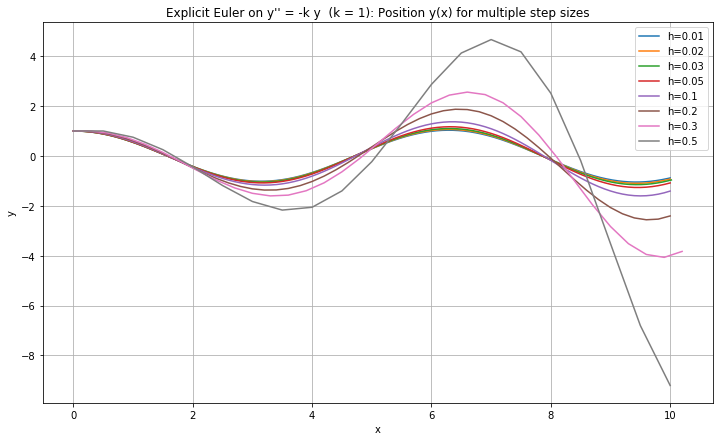

k = 1
----------------------------------------------------------------------
     h |   amp growth |  energy growth |  unstable?
----------------------------------------------------------------------
  0.01 |       1.0513 |         1.1052 |      False
  0.02 |       1.1051 |         1.2214 |       True
  0.03 |       1.1621 |         1.3505 |       True
  0.05 |       1.2836 |         1.6477 |       True
  0.10 |       1.6446 |         2.7048 |       True
  0.20 |       2.6658 |         7.1067 |       True
  0.30 |       4.3276 |        18.7284 |       True
  0.50 |       9.3132 |        86.7362 |       True


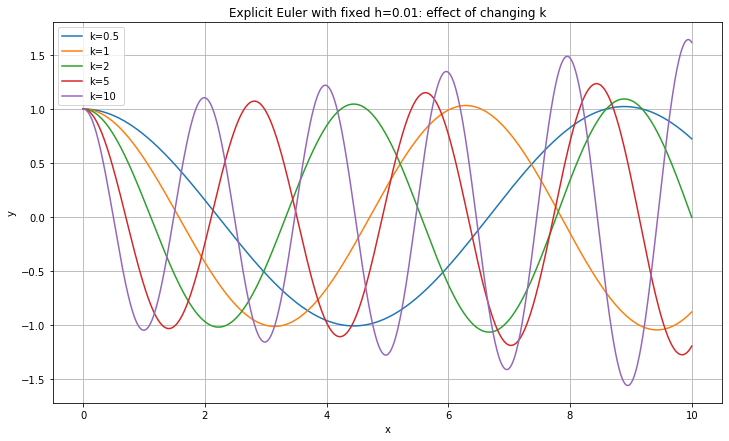

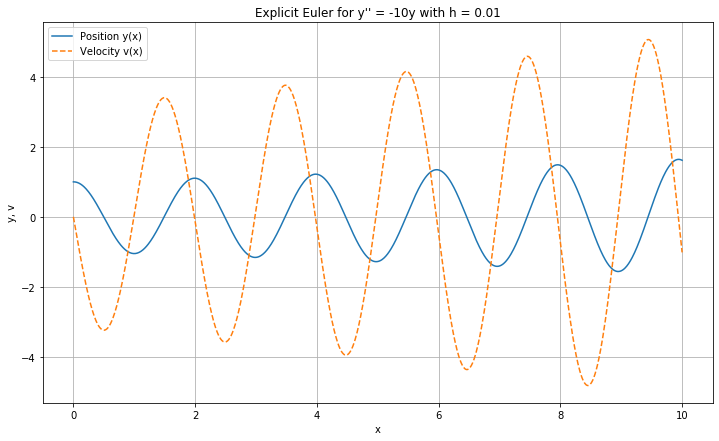

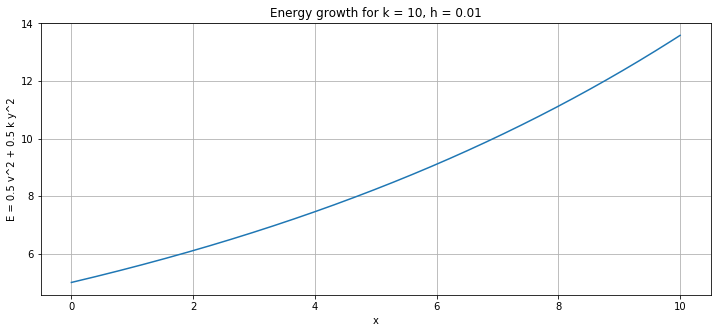


k = 10, h = 0.01
----------------------------------------------------------------------
Amplitude growth factor: 1.909782
Energy growth factor:    2.716924
Unstable?                True


In [2]:
import numpy as np
import matplotlib.pyplot as plt

def euler_sho(k=1.0, h=0.01, x_start=0.0, x_end=10.0, y0=1.0, v0=0.0):
    x_values = np.arange(x_start, x_end + h, h)

    y_values = np.zeros(len(x_values))
    v_values = np.zeros(len(x_values))

    y_values[0] = y0
    v_values[0] = v0

    for i in range(1, len(x_values)):
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]

        # Explicit Euler update
        y_values[i] = y_n + h * v_n
        v_values[i] = v_n + h * (-k * y_n)
        
    return x_values, y_values, v_values

# Stability Analysis
def instability_metrics(y_values, v_values, k):
    amp = np.sqrt(y_values**2 + v_values**2)  # phase-space radius
    energy = 0.5 * v_values**2 + 0.5 * k * y_values**2

    amp_growth = amp[-1] / max(amp[0], 1e-12)
    energy_growth = energy[-1] / max(energy[0], 1e-12)

    # crude flag: if amplitude grows noticeably, call it unstable
    unstable = amp_growth > 1.10
    
    return {
        "amp0": amp[0],
        "amp_end": amp[-1],
        "amp_growth": amp_growth,
        "energy0": energy[0],
        "energy_end": energy[-1],
        "energy_growth": energy_growth,
        "unstable": unstable
    }

# Evaluate at h values and plot
h_list = [0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5]
k = 1.0
x_start = 0.0
x_end = 10.0
y0 = 1.0
v0 = 0.0

results = []

plt.figure(figsize=(12, 7))
for h in h_list:
    x, y, v = euler_sho(k=k, h=h, x_start=x_start, x_end=x_end, y0=y0, v0=v0)
    metrics = instability_metrics(y, v, k)
    results.append((h, metrics))
    plt.plot(x, y, label=f"h={h}")

plt.title("Explicit Euler on y'' = -k y  (k = 1): Position y(x) for multiple step sizes")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

# Print diagnostics
print("k = 1")
print("-" * 70)
print(f"{'h':>6} | {'amp growth':>12} | {'energy growth':>14} | {'unstable?':>10}")
print("-" * 70)
for h, m in results:
    print(f"{h:>6.2f} | {m['amp_growth']:>12.4f} | {m['energy_growth']:>14.4f} | {str(m['unstable']):>10}")

# Change K values
k_values = [0.5, 1, 2, 5, 10]
h_fixed = 0.01

plt.figure(figsize=(12, 7))
for k_test in k_values:
    x, y, v = euler_sho(k=k_test, h=h_fixed, x_start=x_start, x_end=x_end, y0=y0, v0=v0)
    plt.plot(x, y, label=f"k={k_test}")

plt.title(f"Explicit Euler with fixed h={h_fixed}: effect of changing k")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

# Evaluate at k=10, h=0.01
k_special = 10
h_special = 0.01

x, y, v = euler_sho(k=k_special, h=h_special, x_start=x_start, x_end=x_end, y0=y0, v0=v0)
m = instability_metrics(y, v, k_special)

plt.figure(figsize=(12, 7))
plt.plot(x, y, label="Position y(x)")
plt.plot(x, v, "--", label="Velocity v(x)")
plt.title("Explicit Euler for y'' = -10y with h = 0.01")
plt.xlabel("x")
plt.ylabel("y, v")
plt.grid(True)
plt.legend()
plt.show()

energy = 0.5 * v**2 + 0.5 * k_special * y**2
plt.figure(figsize=(12, 5))
plt.plot(x, energy)
plt.title("Energy growth for k = 10, h = 0.01")
plt.xlabel("x")
plt.ylabel("E = 0.5 v^2 + 0.5 k y^2")
plt.grid(True)
plt.show()

print("\nk = 10, h = 0.01")
print("-" * 70)
print(f"Amplitude growth factor: {m['amp_growth']:.6f}")
print(f"Energy growth factor:    {m['energy_growth']:.6f}")
print(f"Unstable?                {m['unstable']}")